<div align="center">

<img src="../img/logo.png" width="380">

# Predicción de Inventario

**Proyecto de Machine Learning — Trazos y Hojas**

</div>

---

### Business Case

**Problema de negocio:** la papelería Trazos y Hojas necesita anticipar cuántas unidades de producto va a necesitar en inventario, para evitar tanto roturas de stock como sobre-stock inmovilizando capital.

**Objetivo de modelado:** predecir, para cada producto y cada día, cuántas unidades se venderán. Es un problema de **regresión supervisada** sobre una serie temporal de ventas.


<h2 style="color:#4A6035;">Exploración inicial de los datos</h2>

Primer vistazo al dataset en bruto tal y como llega del TPV: dimensiones, tipos de dato, missings y primeros registros.

In [3]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# --- Paleta de colores de la marca Trazos y Hojas ---
VERDE_OSCURO = '#4A6035'
MARRON       = '#8F7C52'
VERDE_CLARO  = '#7D955B'
CREMA        = '#EFE6D2'
MOSTAZA      = '#D9A441'
NARANJA      = '#D9824A'

PALETA_MARCA = [VERDE_OSCURO, MARRON, VERDE_CLARO, MOSTAZA, NARANJA, CREMA]
sns.set_palette(sns.color_palette(PALETA_MARCA))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PALETA_MARCA)

In [6]:
# sep=';' -> el archivo usa punto y coma como separador
# encoding='utf-8' -> para que tildes y eñes se lean bien
df = pd.read_csv('../data_sample/DatosBrutos (1).csv', sep=';', encoding='utf-8')

print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Filas: 11613
Columnas: 20


In [7]:
df.columns.tolist()

['Producto',
 'Cantidad',
 'Categoría',
 'Fecha/Hora',
 'Valor del Descuento',
 'Motivo del Descuento',
 'Ventas NETAS',
 'Tipo de Venta',
 'Opción de Comer',
 'Código Fiscal',
 'Impuesto',
 'Ventas TOTALES',
 'Precio de Coste',
 'Margen',
 'Método de Pago',
 'Nominal',
 'A/C Ref',
 'Notas',
 'Identificación del Cliente',
 'ProductId']

In [8]:
# object = texto | float64 = decimal | int64 = entero
df.dtypes

Producto                       object
Cantidad                      float64
Categoría                      object
Fecha/Hora                     object
Valor del Descuento           float64
Motivo del Descuento           object
Ventas NETAS                  float64
Tipo de Venta                  object
Opción de Comer               float64
Código Fiscal                 float64
Impuesto                      float64
Ventas TOTALES                float64
Precio de Coste               float64
Margen                        float64
Método de Pago                 object
Nominal                       float64
A/C Ref                        object
Notas                          object
Identificación del Cliente    float64
ProductId                     float64
dtype: object

In [9]:
df.head(5)

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Motivo del Descuento,Ventas NETAS,Tipo de Venta,Opción de Comer,Código Fiscal,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,Nominal,A/C Ref,Notas,Identificación del Cliente,ProductId
0,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,06/07/2026 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.0400,1.4000,Tarjeta,NaN,NaN,NaN,NaN,2152893.0
1,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,06/07/2026 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.0400,1.4000,Tarjeta,NaN,NaN,NaN,NaN,2152893.0
2,Copia A4 B/N,1.0,Copisteria,06/07/2026 10:02:41,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.0500,0.0700,Efectivo,NaN,NaN,NaN,NaN,2160044.0
3,Panini Cromos Mundial 2026,5.0,Otros,04/07/2026 14:00:23,0.0,NaN,6.20,Eat in,0.0,NaN,1.30,7.50,5.0355,1.1645,Tarjeta,NaN,NaN,NaN,NaN,2336673.0
4,Copia A4 B/N,1.0,Copisteria,04/07/2026 13:50:04,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.0500,0.0700,Efectivo,NaN,NaN,NaN,NaN,2160044.0


In [10]:
missings_abs = df.isna().sum()
missings_pct = (df.isna().sum() / len(df) * 100).round(1)

tabla_missings = pd.DataFrame({
    'Missings (nº)': missings_abs,
    'Missings (%)': missings_pct
}).sort_values('Missings (%)', ascending=False)

tabla_missings

,Missings (nº),Missings (%)
Nominal,11613,100.0
A/C Ref,11610,100.0
Código Fiscal,11613,100.0
Notas,11607,99.9
Motivo del Descuento,11447,98.6
Identificación del Cliente,11002,94.7
Categoría,390,3.4
Producto,1,0.0
Fecha/Hora,1,0.0
Cantidad,1,0.0


**Conclusiones de la exploración inicial**

- El dataset contiene el detalle línea a línea de cada venta del TPV; la agregación por día se hará al construir el target.
- Columnas con missing muy alto (`Código Fiscal`, `Nominal`, `A/C Ref`, `Notas`, `Identificación del Cliente`) son candidatas a descartar.
- `Fecha/Hora` está en texto y debe convertirse a `datetime`.

<h2 style="color:#4A6035;">Variables del dataset y definición del objetivo a predecir</h2>

Documentamos las variables disponibles y definimos formalmente el target. **La selección final de qué productos entran al modelo se deja para el último apartado de este notebook**, una vez hecho el resto del análisis.

In [11]:
tabla_variables = pd.DataFrame([
    {'Variable': 'Producto',              'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Identificador del producto. Feature categórica del modelo global.'},
    {'Variable': 'Cantidad',               'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Base de la variable TARGET (unidades vendidas).'},
    {'Variable': 'Categoría',              'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Posible feature adicional (familia de producto).'},
    {'Variable': 'Fecha/Hora',             'Tipo': 'object',  'Naturaleza': 'Fecha',      'Aporte esperado': 'Base temporal para agregar por día y derivar features (día de semana, mes...).'},
    {'Variable': 'Valor del Descuento',    'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Podría explicar picos de demanda puntuales.'},
    {'Variable': 'Motivo del Descuento',   'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Bajo, muchos missings.'},
    {'Variable': 'Ventas NETAS',           'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Usada para el análisis de selección de productos, no como feature (fuga de información).'},
    {'Variable': 'Tipo de Venta',          'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Posible feature.'},
    {'Variable': 'Opción de Comer',        'Tipo': 'int64',   'Naturaleza': 'Categórica', 'Aporte esperado': 'Bajo aporte esperado.'},
    {'Variable': 'Código Fiscal',          'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'Impuesto',               'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Derivable del precio, redundante.'},
    {'Variable': 'Ventas TOTALES',         'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Correlacionada con Ventas NETAS.'},
    {'Variable': 'Precio de Coste',        'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Posible feature de precio.'},
    {'Variable': 'Margen',                 'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Relacionado con precio/coste, revisar colinealidad.'},
    {'Variable': 'Método de Pago',         'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Bajo aporte esperado.'},
    {'Variable': 'Nominal',                'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'A/C Ref',                'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'Notas',                  'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'Identificación del Cliente', 'Tipo': 'object', 'Naturaleza': 'Categórica', 'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'ProductId',              'Tipo': 'int64',   'Naturaleza': 'Categórica', 'Aporte esperado': 'Redundante con Producto.'},
])

tabla_variables

,Variable,Tipo,Naturaleza,Aporte esperado
0,Producto,object,Categórica,Identificador del producto. Feature categórica...
1,Cantidad,float64,Numérica,Base de la variable TARGET (unidades vendidas).
2,Categoría,object,Categórica,Posible feature adicional (familia de producto).
3,Fecha/Hora,object,Fecha,Base temporal para agregar por día y derivar f...
4,Valor del Descuento,float64,Numérica,Podría explicar picos de demanda puntuales.
5,Motivo del Descuento,object,Categórica,"Bajo, muchos missings."
6,Ventas NETAS,float64,Numérica,Usada para el análisis de selección de product...
7,Tipo de Venta,object,Categórica,Posible feature.
8,Opción de Comer,int64,Categórica,Bajo aporte esperado.
9,Código Fiscal,float64,Numérica,Descartar: ~100% missing.


**Construcción del target: unidades vendidas por producto y día**

1. Convertimos `Fecha/Hora` a fecha (sin hora).
2. Agregamos `Cantidad` por `Producto` y `Fecha`.
3. Completamos con 0 las combinaciones producto-día sin venta.

De momento lo hacemos sobre **todos** los productos; el filtrado a los que son aptos para modelar se hace al final del notebook.

In [12]:
df['Fecha/Hora'] = pd.to_datetime(df['Fecha/Hora'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df = df.dropna(subset=['Fecha/Hora'])
df['Fecha'] = df['Fecha/Hora'].dt.date
df['Semana'] = df['Fecha/Hora'].dt.to_period('W')

ventas_diarias = df.groupby(['Producto', 'Fecha'])['Cantidad'].sum().reset_index()
ventas_diarias.columns = ['Producto', 'Fecha', 'Unidades_Vendidas']
ventas_diarias.head()

,Producto,Fecha,Unidades_Vendidas
0,10 Colores Mickey,2026-03-09,1.0
1,1200 Amarillo C-005,2026-03-07,1.0
2,1200 Amarillo C-005,2026-03-19,1.0
3,1200 Amarillo C-005,2026-05-11,1.0
4,1200 Amarillo C-005,2026-05-22,1.0


<h2 style="color:#4A6035;">División temporal en entrenamiento y test</h2>

Al ser una serie temporal, el split **no puede ser aleatorio**: se hace por fecha de corte. Reservamos las últimas 3 semanas como test y el resto como train. A partir de aquí, todo el análisis se hace solo sobre train.

In [13]:
fecha_max = df['Fecha'].max()
fecha_corte = pd.Timestamp(fecha_max) - pd.Timedelta(weeks=3)
fecha_corte = fecha_corte.date()

train = df[df['Fecha'] < fecha_corte].copy()
test = df[df['Fecha'] >= fecha_corte].copy()

print(f'Fecha de corte: {fecha_corte}')
print(f'Train: {train["Fecha"].min()} a {train["Fecha"].max()} ({train["Fecha"].nunique()} días, {len(train)} filas)')
print(f'Test:  {test["Fecha"].min()} a {test["Fecha"].max()} ({test["Fecha"].nunique()} días, {len(test)} filas)')

Fecha de corte: 2026-06-15
Train: 2026-01-19 a 2026-06-13 (119 días, 10128 filas)
Test:  2026-06-15 a 2026-07-06 (19 días, 1484 filas)


<h2 style="color:#4A6035;">Análisis de la demanda diaria (variable objetivo)</h2>

Analizamos, sobre train, cómo se distribuye la demanda diaria total y detectamos el problema de los ceros / asimetría.

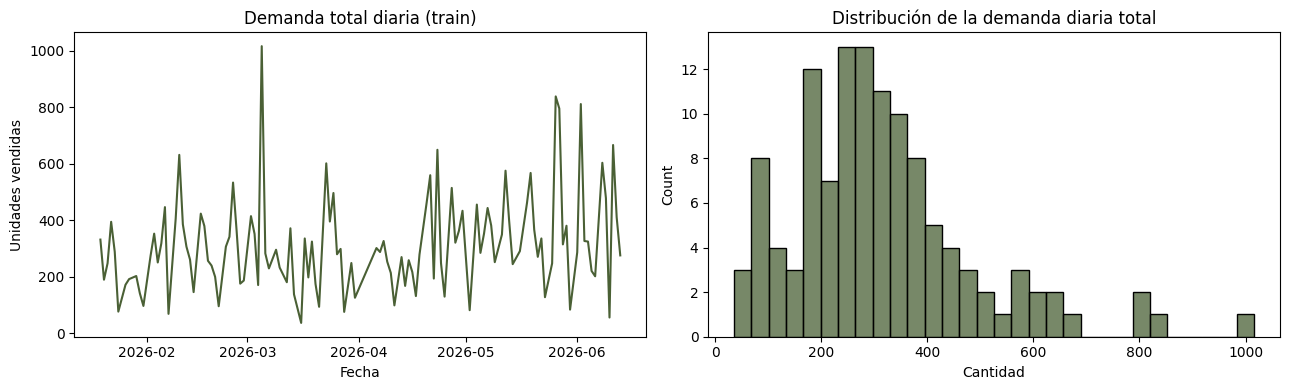

count     119.000000
mean      314.512605
std       172.085802
min        36.000000
25%       200.000000
50%       287.000000
75%       383.000000
max      1016.000000
Name: Cantidad, dtype: float64


In [14]:
demanda_diaria_total = train.groupby('Fecha')['Cantidad'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
demanda_diaria_total.plot(ax=axes[0], color=VERDE_OSCURO, title='Demanda total diaria (train)')
axes[0].set_ylabel('Unidades vendidas')
sns.histplot(demanda_diaria_total, bins=30, ax=axes[1], color=VERDE_OSCURO)
axes[1].set_title('Distribución de la demanda diaria total')
plt.tight_layout()
plt.show()

print(demanda_diaria_total.describe())

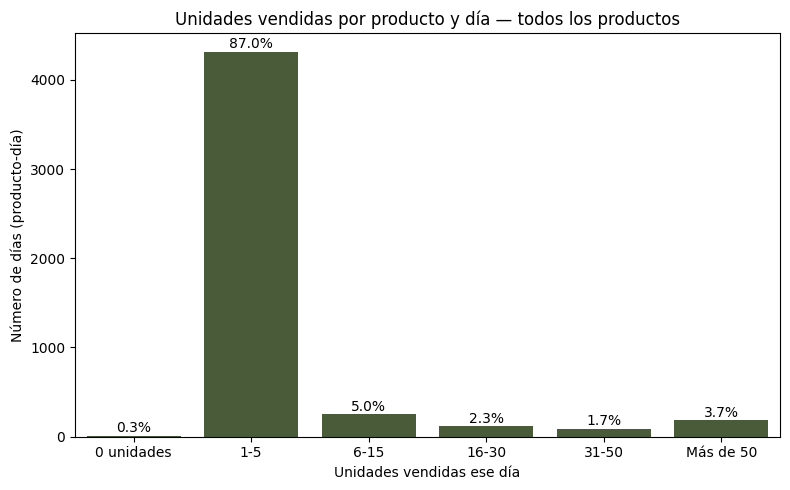

Producto-día con 0 ventas en train: 0.3%


In [15]:
# Distribución a nivel producto-día, agrupando en rangos simples (más fácil de leer que una escala logarítmica)
target_train = ventas_diarias[ventas_diarias['Fecha'] < fecha_corte].copy()

bins = [-1, 0, 5, 15, 30, 50, float('inf')]
labels = ['0 unidades', '1-5', '6-15', '16-30', '31-50', 'Más de 50']
target_train['Grupo'] = pd.cut(target_train['Unidades_Vendidas'], bins=bins, labels=labels)

conteo = target_train['Grupo'].value_counts().reindex(labels)
porcentaje = (conteo / conteo.sum() * 100).round(1)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=conteo.index, y=conteo.values, color=VERDE_OSCURO)
plt.title('Unidades vendidas por producto y día — todos los productos')
plt.ylabel('Número de días (producto-día)')
plt.xlabel('Unidades vendidas ese día')

for i, (v, p) in enumerate(zip(conteo.values, porcentaje.values)):
    ax.text(i, v + max(conteo.values)*0.01, f'{p}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Producto-día con 0 ventas en train: {porcentaje["0 unidades"]}%')

**Observaciones:** la variable target a nivel producto-día tiene un porcentaje altísimo de ceros — esperable dado que estamos mirando aún los 1.012 productos, muchos con venta esporádica. Este problema se reduce mucho en la sección final, al quedarnos solo con los productos aptos para modelar.

<h2 style="color:#4A6035;">Relación entre las ventas y otras variables</h2>

Miramos cómo varía la demanda diaria total según el día de la semana y el mes, y su relación con el precio.

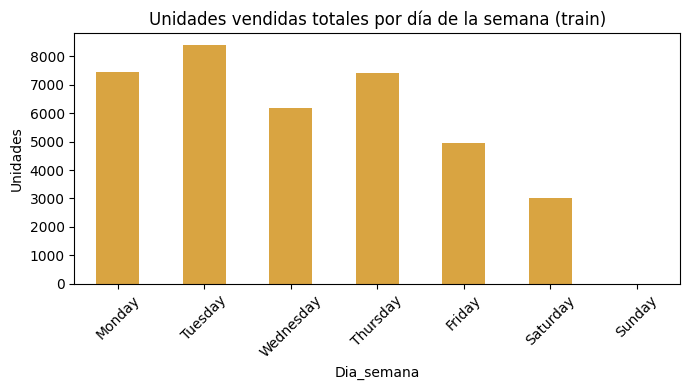

In [16]:
train['Dia_semana'] = pd.to_datetime(train['Fecha']).dt.day_name()
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

demanda_por_dia = train.groupby('Dia_semana')['Cantidad'].sum().reindex(orden_dias)

plt.figure(figsize=(7,4))
demanda_por_dia.plot(kind='bar', color=MOSTAZA)
plt.title('Unidades vendidas totales por día de la semana (train)')
plt.ylabel('Unidades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

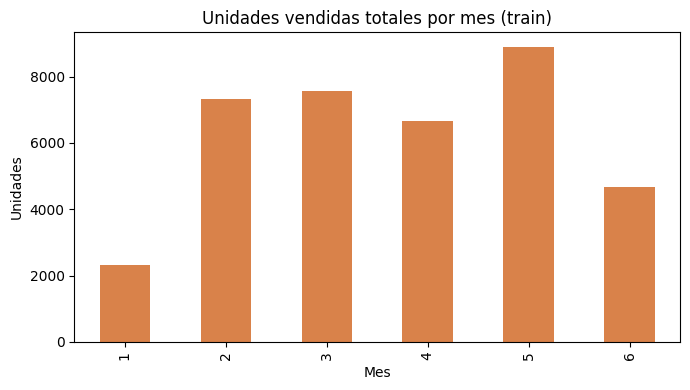

In [17]:
train['Mes'] = pd.to_datetime(train['Fecha']).dt.month

demanda_por_mes = train.groupby('Mes')['Cantidad'].sum()

plt.figure(figsize=(7,4))
demanda_por_mes.plot(kind='bar', color=NARANJA)
plt.title('Unidades vendidas totales por mes (train)')
plt.ylabel('Unidades')
plt.tight_layout()
plt.show()

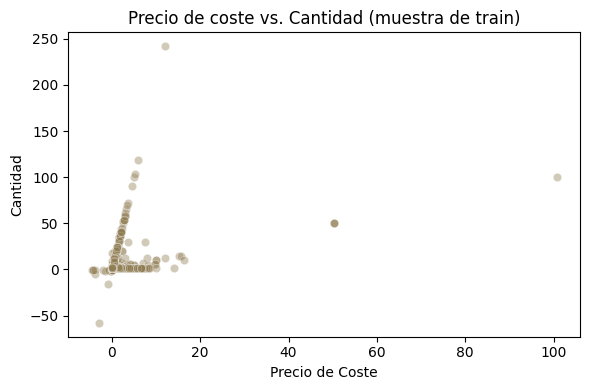

In [18]:
# Relación precio de coste vs cantidad vendida (a nivel línea de venta)
plt.figure(figsize=(6,4))
sns.scatterplot(data=train.sample(min(2000, len(train)), random_state=42), x='Precio de Coste', y='Cantidad', alpha=0.4, color=MARRON)
plt.title('Precio de coste vs. Cantidad (muestra de train)')
plt.tight_layout()
plt.show()

<h2 style="color:#4A6035;">Correlación entre variables numéricas</h2>

Revisamos la correlación entre las variables numéricas para detectar multicolinealidad (esperable entre Precio de Coste, Margen y Ventas).

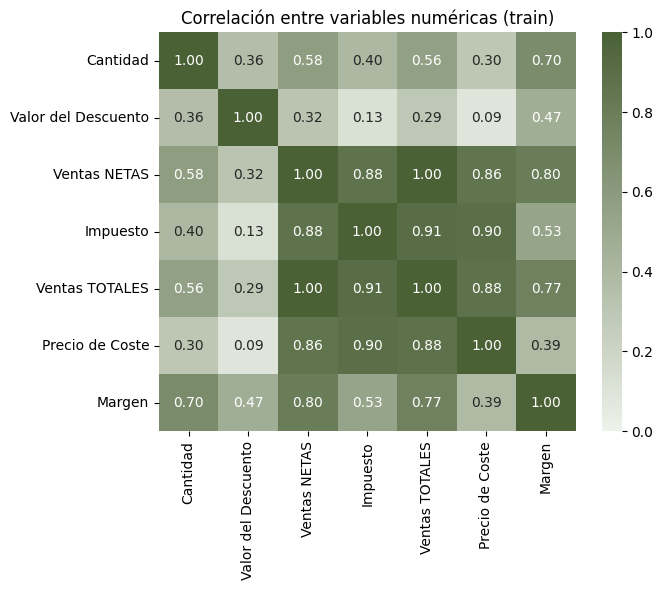

In [19]:
num_cols = ['Cantidad', 'Valor del Descuento', 'Ventas NETAS', 'Impuesto', 'Ventas TOTALES', 'Precio de Coste', 'Margen']
corr = train[num_cols].corr()

mapa_marca = sns.light_palette(VERDE_OSCURO, as_cmap=True)

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=mapa_marca, vmin=0, vmax=1)
plt.title('Correlación entre variables numéricas (train)')
plt.tight_layout()
plt.show()

**Observación esperada:** `Ventas TOTALES`, `Ventas NETAS`, `Impuesto` y `Precio de Coste` deberían mostrar alta colinealidad entre sí (todas derivan del precio de venta). No usarlas todas juntas como features del modelo.

<h2 style="color:#4A6035;">Detección de días con demanda atípica</h2>

Buscamos picos de demanda anómalos en la serie diaria total, usando el método IQR.

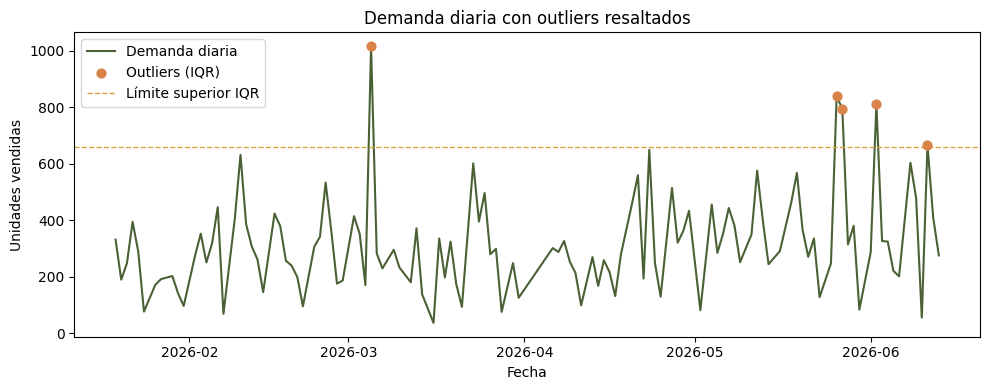

Límite superior (IQR): 658 unidades/día
Días considerados outlier: 5


Fecha
2026-03-05    1016.0
2026-05-26     838.0
2026-05-27     795.0
2026-06-02     811.0
2026-06-11     666.0
Name: Cantidad, dtype: float64

In [20]:
q1 = demanda_diaria_total.quantile(0.25)
q3 = demanda_diaria_total.quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

outliers = demanda_diaria_total[demanda_diaria_total > limite_superior]

plt.figure(figsize=(10,4))
demanda_diaria_total.plot(color=VERDE_OSCURO, label='Demanda diaria')
plt.scatter(outliers.index, outliers.values, color=NARANJA, zorder=5, label='Outliers (IQR)', s=40)
plt.axhline(limite_superior, color=MOSTAZA, linestyle='--', linewidth=1, label='Límite superior IQR')
plt.title('Demanda diaria con outliers resaltados')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Límite superior (IQR): {limite_superior:.0f} unidades/día')
print(f'Días considerados outlier: {len(outliers)}')
outliers

**Observación:** conviene revisar manualmente estos días para distinguir entre "ruido" real y picos legítimos y repetibles (como campañas de Panini o vuelta al cole), que no deberían tratarse igual que un error de registro.

<h2 style="color:#4A6035;">Selección de productos para el modelado</h2>

De los 1.012 productos del dataset, la mayoría se venden de forma demasiado esporádica para modelar de forma fiable. Definimos 3 reglas para considerar un producto **apto**:

1. **Al menos 30 transacciones** en todo el periodo (para que el modelo no memorice en vez de aprender un patrón).
2. **Venta en al menos 15 de las 25 semanas** del periodo (para asegurar que haya muestras representativas también en test).
3. **Coeficiente de Variación (CV) semanal por debajo de 1.2** (desviación estándar / media de las unidades vendidas por semana), para descartar productos demasiado erráticos que metan ruido al modelo.

Un producto debe cumplir **las 3 reglas a la vez** para considerarse apto.

In [21]:
semanas_totales = df['Semana'].nunique()
todas_semanas = sorted(df['Semana'].unique())
print(f'Número total de semanas en el periodo: {semanas_totales}')

Número total de semanas en el periodo: 25


In [22]:
# Regla 1: número de transacciones (líneas de venta) por producto
transacciones = df.groupby('Producto').size()

# Regla 2: número de semanas distintas con venta, por producto
semanas_con_venta = df.groupby('Producto')['Semana'].nunique()

# Regla 3: CV semanal -> construimos la serie semanal completa (25 semanas, con 0 donde no hubo venta)
ventas_semanales = df.groupby(['Producto', 'Semana'])['Cantidad'].sum().reset_index()

productos_todos = df['Producto'].unique()
indice_semanal = pd.MultiIndex.from_product([productos_todos, todas_semanas], names=['Producto', 'Semana'])

panel_semanal = (
    ventas_semanales
    .set_index(['Producto', 'Semana'])
    .reindex(indice_semanal, fill_value=0)
    .reset_index()
)

def calcular_cv(x):
    return x.std() / x.mean() if x.mean() > 0 else np.inf

cv_semanal = panel_semanal.groupby('Producto')['Cantidad'].apply(calcular_cv)

# Juntamos las 3 métricas en una tabla resumen
resumen_seleccion = pd.DataFrame({
    'Transacciones': transacciones,
    'Semanas_con_venta': semanas_con_venta,
    'CV_semanal': cv_semanal
})

resumen_seleccion.head()

,Transacciones,Semanas_con_venta,CV_semanal
Producto,,,
10 Colores Mickey,1,1,5.000000
1200 Amarillo C-005,4,4,2.338536
1200 Azul C-010,5,5,2.041241
1200 Naranja Fluo C-066,3,3,2.763854
1200 Oro C-053,1,1,5.000000


In [23]:
# Aplicamos las 3 reglas
resumen_seleccion['Cumple_transacciones'] = resumen_seleccion['Transacciones'] >= 30
resumen_seleccion['Cumple_semanas'] = resumen_seleccion['Semanas_con_venta'] >= 15
resumen_seleccion['Cumple_CV'] = resumen_seleccion['CV_semanal'] < 1.2
resumen_seleccion['Apto_para_modelar'] = (
    resumen_seleccion['Cumple_transacciones']
    & resumen_seleccion['Cumple_semanas']
    & resumen_seleccion['Cumple_CV']
)

print('Productos que cumplen cada regla por separado:')
print(f'  >= 30 transacciones:      {resumen_seleccion["Cumple_transacciones"].sum()}')
print(f'  >= 15 de 25 semanas:      {resumen_seleccion["Cumple_semanas"].sum()}')
print(f'  CV semanal < 1.2:         {resumen_seleccion["Cumple_CV"].sum()}')
print()
print(f'Productos APTOS (cumplen las 3 reglas): {resumen_seleccion["Apto_para_modelar"].sum()} de {len(resumen_seleccion)}')

Productos que cumplen cada regla por separado:
  >= 30 transacciones:      46
  >= 15 de 25 semanas:      49
  CV semanal < 1.2:         43

Productos APTOS (cumplen las 3 reglas): 31 de 1012


In [24]:
productos_aptos = resumen_seleccion[resumen_seleccion['Apto_para_modelar']].sort_values('Transacciones', ascending=False)
productos_aptos

,Transacciones,Semanas_con_venta,CV_semanal,Cumple_transacciones,Cumple_semanas,Cumple_CV,Apto_para_modelar
Producto,,,,,,,
Copia A4 B/N,2605,25,0.440053,True,True,True,True
Doble Cara A4 B/N,988,24,0.730152,True,True,True,True
Copia A4 Color,670,24,0.664005,True,True,True,True
1ª Página,284,24,0.509124,True,True,True,True
Servicio menor a 1 hora,265,24,0.879170,True,True,True,True
Etiqueta Blanco y Negro,127,23,0.788035,True,True,True,True
Doble Cara A4 Color,115,23,0.930628,True,True,True,True
Encuadernación peq,91,22,1.026274,True,True,True,True
Navigator 80,89,22,0.622279,True,True,True,True


In [25]:
# Dataset final de target, filtrado a los productos aptos
productos_seleccionados = productos_aptos.index.tolist()

target_final = ventas_diarias[ventas_diarias['Producto'].isin(productos_seleccionados)].copy()

# Completar dias sin venta con 0, para el conjunto final de productos
todas_las_fechas = pd.date_range(df['Fecha'].min(), df['Fecha'].max(), freq='D').date
indice_final = pd.MultiIndex.from_product([productos_seleccionados, todas_las_fechas], names=['Producto', 'Fecha'])

target_final = (
    target_final
    .set_index(['Producto', 'Fecha'])
    .reindex(indice_final, fill_value=0)
    .reset_index()
)

print(f'Dataset final: {len(productos_seleccionados)} productos x {len(todas_las_fechas)} días = {len(target_final)} filas')
print(f'Porcentaje de ceros en el dataset final: {(target_final["Unidades_Vendidas"]==0).mean()*100:.1f}%')
target_final.head()

Dataset final: 31 productos x 169 días = 5239 filas
Porcentaje de ceros en el dataset final: 69.2%


,Producto,Fecha,Unidades_Vendidas
0,Copia A4 B/N,2026-01-19,133.0
1,Copia A4 B/N,2026-01-20,94.0
2,Copia A4 B/N,2026-01-21,92.0
3,Copia A4 B/N,2026-01-22,142.0
4,Copia A4 B/N,2026-01-23,51.0


**Conclusión de la selección:** de 1.012 productos, **31 cumplen las 3 reglas** y forman el universo final sobre el que se construirá el modelo. Es un conjunto bastante más exigente que un simple ranking por ingresos: combina volumen suficiente (transacciones), regularidad (semanas activas) y estabilidad (CV), que son justo los tres requisitos que hacen que un producto sea predecible de forma fiable.

**Entregable de esta sección:** `target_final` — dataset con Producto, Fecha y Unidades_Vendidas para los 31 productos aptos, listo para que el resto del equipo continúe con preprocesado y feature engineering.

In [26]:
# Guardamos el dataset final para que el compañero de preprocesado lo pueda cargar directamente
target_final.to_csv('../data_sample/target_final.csv', index=False)
print('Guardado: target_final.csv')

Guardado: target_final.csv


<h2 style="color:#4A6035;">Pre- Processing</h2>

Basado en que solo 31 productos de los 1.012 cumplen con las 3 reglas establecidas previamente, se debe realizar la limpieza correcta de los datos dejando las columnas correspondientes. 



In [27]:
#Librerías
from sklearn.preprocessing import StandardScaler
from scipy import stats


In [28]:
df_raw = pd.read_csv('../data_sample/DatosBrutos (1).csv', sep=';', encoding='utf-8')

df_raw['Fecha/Hora'] = pd.to_datetime(df_raw['Fecha/Hora'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df_raw = df_raw.dropna(subset=['Fecha/Hora'])
df_raw['Fecha'] = df_raw['Fecha/Hora'].dt.date
df_raw['Semana'] = df_raw['Fecha/Hora'].dt.to_period('W')
print(f'Filas datos crudos: {len(df_raw)}')

Filas datos crudos: 11612


In [29]:
display(df_raw)

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Motivo del Descuento,Ventas NETAS,Tipo de Venta,Opción de Comer,Código Fiscal,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,Nominal,A/C Ref,Notas,Identificación del Cliente,ProductId,Fecha,Semana
0,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,2026-07-06 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.0400,1.4000,Tarjeta,NaN,NaN,NaN,NaN,2152893.0,2026-07-06,2026-07-06/2026-07-12
1,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,2026-07-06 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.0400,1.4000,Tarjeta,NaN,NaN,NaN,NaN,2152893.0,2026-07-06,2026-07-06/2026-07-12
2,Copia A4 B/N,1.0,Copisteria,2026-07-06 10:02:41,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.0500,0.0700,Efectivo,NaN,NaN,NaN,NaN,2160044.0,2026-07-06,2026-07-06/2026-07-12
3,Panini Cromos Mundial 2026,5.0,Otros,2026-07-04 14:00:23,0.0,NaN,6.20,Eat in,0.0,NaN,1.30,7.50,5.0355,1.1645,Tarjeta,NaN,NaN,NaN,NaN,2336673.0,2026-07-04,2026-06-29/2026-07-05
4,Copia A4 B/N,1.0,Copisteria,2026-07-04 13:50:04,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.0500,0.0700,Efectivo,NaN,NaN,NaN,NaN,2160044.0,2026-07-04,2026-06-29/2026-07-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11607,Copia A4 B/N,7.0,Copisteria,2026-01-19 10:45:22,0.0,NaN,1.05,Eat in,0.0,NaN,0.00,1.05,0.3500,0.7000,Efectivo,NaN,NaN,NaN,NaN,2160044.0,2026-01-19,2026-01-19/2026-01-25
11608,Copia A4 B/N,2.0,Copisteria,2026-01-19 10:34:46,0.0,NaN,0.30,Eat in,0.0,NaN,0.00,0.30,0.1000,0.2000,Efectivo,NaN,NaN,NaN,NaN,2160044.0,2026-01-19,2026-01-19/2026-01-25
11609,Copia A4 B/N,4.0,Copisteria,2026-01-19 10:04:35,0.0,NaN,0.60,Eat in,0.0,NaN,0.00,0.60,0.2000,0.4000,Efectivo,NaN,NaN,NaN,NaN,2160044.0,2026-01-19,2026-01-19/2026-01-25
11610,Copia A4 B/N,4.0,Copisteria,2026-01-19 09:49:10,0.0,NaN,0.60,Eat in,0.0,NaN,0.00,0.60,0.2000,0.4000,Efectivo,NaN,NaN,NaN,NaN,2160044.0,2026-01-19,2026-01-19/2026-01-25


In [30]:
target_final = pd.read_csv('../data_sample/target_final.csv', sep=',', encoding='utf-8')
target_final.Producto.value_counts()


Producto
Copia A4 B/N                         169
Doble Cara A4 B/N                    169
Copia A4 Color                       169
1ª Página                            169
Servicio menor a 1 hora              169
Etiqueta Blanco y Negro              169
Doble Cara A4 Color                  169
Encuadernación peq                   169
Navigator 80                         169
Sobre Velcro A4 Ref 90111 variado    169
Sobre Americano Open 115             169
Copia A3 Color                       169
Cristal Original Azul 1.0            169
Cartulinas Colores 50x65             169
Pegamento Barra Pritt 20g            169
Noris HB                             169
Pegamento Barra Pritt 11g            169
Sobre con fuelle  Velcro. A4         169
Tippex Pocket Mouse 10m              169
Bolsa Kraft pequeña                  169
G2 0.7 Azul                          169
TippEx Micro tape Twist              169
Cristal Fine Azul 0.8                169
Papel de regalo Design 0.7x2m        169
Super G

In [31]:
#Conversion de la columna 'Fecha' a tipo datetime
target_final['Fecha'] = pd.to_datetime(target_final['Fecha'])
target_final=target_final.sort_values(by=['Producto','Fecha']).reset_index(drop=True)

In [32]:
#Creación de columnas partiendo de los datos de fecha
target_final['Dia_semana']=target_final['Fecha'].dt.dayofweek
target_final['Fin_de_semana'] = target_final['Dia_semana'].isin([5,6]).astype(int)
target_final['Dia_mes']=target_final['Fecha'].dt.day
target_final['Mes']=target_final['Fecha'].dt.month
target_final['Semana_year']= target_final['Fecha'].dt.isocalendar().week.astype(int)


In [33]:
display(target_final)

,Producto,Fecha,Unidades_Vendidas,Dia_semana,Fin_de_semana,Dia_mes,Mes,Semana_year
0,1ª Página,2026-01-19,1.0,0,0,19,1,4
1,1ª Página,2026-01-20,0.0,1,0,20,1,4
2,1ª Página,2026-01-21,0.0,2,0,21,1,4
3,1ª Página,2026-01-22,3.0,3,0,22,1,4
4,1ª Página,2026-01-23,2.0,4,0,23,1,4
...,...,...,...,...,...,...,...,...
5234,Tippex Pocket Mouse 10m,2026-07-02,0.0,3,0,2,7,27
5235,Tippex Pocket Mouse 10m,2026-07-03,0.0,4,0,3,7,27
5236,Tippex Pocket Mouse 10m,2026-07-04,0.0,5,1,4,7,27
5237,Tippex Pocket Mouse 10m,2026-07-05,0.0,6,1,5,7,27


<h2 style="color:#4A6035;">Evaluación de Lags</h2>

Utilizado para calcular cuanto se vendio hace una semana. Teoricamente funciona de la siguiente manera: 
1. Lag_1: unidades vendidas el día anterior
2. lag_7: unidades vendidas exactamente hace 7 días. Esto para hacer coincidr con el mismo día de la semana anterior


Aquí exisitira un pequeño "problema" que es los valores NaN, estos valores son asociados a lag_1, ya que para cada producto no exisitira un valor de lag_1 ya que no lo tendra como medir, ya que no puedes contar las ventas del día anterior a tu inicio de ventas. Estos NaN posteriormente se solucionarán remplazando los NaN por 0, así no se altera el resultado. 


In [34]:
calculo_lags=target_final.groupby('Producto')['Unidades_Vendidas']

target_final['lag_1'] = calculo_lags.shift(1)
target_final['lag_7'] = calculo_lags.shift(7)
target_final['media_movil_7'] = calculo_lags.transform(lambda x: x.shift(1).rolling(7).mean())
target_final['media_movil_14'] = calculo_lags.transform(lambda x: x.shift(1).rolling(14).mean())
target_final['std_movil_7']    = calculo_lags.transform(lambda x: x.shift(1).rolling(7).std())

cols_lag = ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7']
print('NaN por variable (arranque de cada serie de producto):')
print(target_final[cols_lag].isna().sum())
display(target_final)



NaN por variable (arranque de cada serie de producto):
lag_1              31
lag_7             217
media_movil_7     217
media_movil_14    434
std_movil_7       217
dtype: int64


,Producto,Fecha,Unidades_Vendidas,Dia_semana,Fin_de_semana,Dia_mes,Mes,Semana_year,lag_1,lag_7,media_movil_7,media_movil_14,std_movil_7
0,1ª Página,2026-01-19,1.0,0,0,19,1,4,NaN,NaN,NaN,NaN,NaN
1,1ª Página,2026-01-20,0.0,1,0,20,1,4,1.0,NaN,NaN,NaN,NaN
2,1ª Página,2026-01-21,0.0,2,0,21,1,4,0.0,NaN,NaN,NaN,NaN
3,1ª Página,2026-01-22,3.0,3,0,22,1,4,0.0,NaN,NaN,NaN,NaN
4,1ª Página,2026-01-23,2.0,4,0,23,1,4,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5234,Tippex Pocket Mouse 10m,2026-07-02,0.0,3,0,2,7,27,0.0,1.0,0.142857,0.071429,0.377964
5235,Tippex Pocket Mouse 10m,2026-07-03,0.0,4,0,3,7,27,0.0,0.0,0.000000,0.071429,0.000000
5236,Tippex Pocket Mouse 10m,2026-07-04,0.0,5,1,4,7,27,0.0,0.0,0.000000,0.071429,0.000000
5237,Tippex Pocket Mouse 10m,2026-07-05,0.0,6,1,5,7,27,0.0,0.0,0.000000,0.071429,0.000000


In [35]:
#Una vez comprado la existencia de los NaN como se describe en el apartado anterior se procede a cambiarlos por 0

target_final[cols_lag] = target_final[cols_lag].fillna(0)
display(target_final)

,Producto,Fecha,Unidades_Vendidas,Dia_semana,Fin_de_semana,Dia_mes,Mes,Semana_year,lag_1,lag_7,media_movil_7,media_movil_14,std_movil_7
0,1ª Página,2026-01-19,1.0,0,0,19,1,4,0.0,0.0,0.000000,0.000000,0.000000
1,1ª Página,2026-01-20,0.0,1,0,20,1,4,1.0,0.0,0.000000,0.000000,0.000000
2,1ª Página,2026-01-21,0.0,2,0,21,1,4,0.0,0.0,0.000000,0.000000,0.000000
3,1ª Página,2026-01-22,3.0,3,0,22,1,4,0.0,0.0,0.000000,0.000000,0.000000
4,1ª Página,2026-01-23,2.0,4,0,23,1,4,3.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5234,Tippex Pocket Mouse 10m,2026-07-02,0.0,3,0,2,7,27,0.0,1.0,0.142857,0.071429,0.377964
5235,Tippex Pocket Mouse 10m,2026-07-03,0.0,4,0,3,7,27,0.0,0.0,0.000000,0.071429,0.000000
5236,Tippex Pocket Mouse 10m,2026-07-04,0.0,5,1,4,7,27,0.0,0.0,0.000000,0.071429,0.000000
5237,Tippex Pocket Mouse 10m,2026-07-05,0.0,6,1,5,7,27,0.0,0.0,0.000000,0.071429,0.000000


<h2 style="color:#4A6035;">Nuevas Categorias</h2>


In [36]:
def moda_segura(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

info_producto = (
    df_raw.groupby('Producto')
    .agg(Categoria=('Categoría', moda_segura),
         Precio=('Precio de Coste', 'mean'))
    .reset_index()
)

target_final = target_final.merge(info_producto, on='Producto', how='left')
target_final['Categoria'] = target_final['Categoria'].fillna('Sin categoría')  # evita NaN de cara a MI/SFM/RFE/SFS
target_final['tendencia_7_14'] = target_final['media_movil_7'] - target_final['media_movil_14']

target_final[['Producto', 'Categoria', 'Precio', 'tendencia_7_14']].head()

,Producto,Categoria,Precio,tendencia_7_14
0,1ª Página,Copisteria,0.050352,0.0
1,1ª Página,Copisteria,0.050352,0.0
2,1ª Página,Copisteria,0.050352,0.0
3,1ª Página,Copisteria,0.050352,0.0
4,1ª Página,Copisteria,0.050352,0.0



<h2 style="color:#4A6035;">Division de datos al igual que en el EDA</h2>

In [37]:
fecha_corte = target_final['Fecha'].max() - pd.Timedelta(weeks=3)

train = target_final[target_final['Fecha'] < fecha_corte].copy()
test  = target_final[target_final['Fecha'] >= fecha_corte].copy()

print(f'Fecha de corte: {fecha_corte.date()}')
print(f'Train: {train.shape[0]} filas | Test: {test.shape[0]} filas')

Fecha de corte: 2026-06-15
Train: 4557 filas | Test: 682 filas


<h2 style="color:#4A6035;">Selección estadística de features</h2>



Antes de codificar y escalar, comprobamos qué variables tienen relación real con el target
(`Unidades_Vendidas`), usando el test adecuado según el tipo de cada variable de entrada. El
target es siempre numérico, así que solo miramos la rama "Output = Numérica":

| Tipo de feature | Test | Variables |
|---|---|---|
| Numérica → Numérica | Pearson (lineal) y Spearman (monótona, robusta a outliers) | lags, medias móviles, tendencia, precio |
| Categórica → Numérica | ANOVA (paramétrico)| Producto, Categoria, Dia_semana, Mes, Es_fin_de_semana |

Usamos **Spearman como criterio principal** por encima de Pearson: el target tiene bastantes ceros
y valores puntuales altos (visto en la EDA), por lo que la relación con los lags es probablemente
monótona pero no estrictamente lineal, y Spearman es más robusto a esa asimetría.

In [38]:
#Pearson y Spearman
features_numericas = ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14','std_movil_7', 'tendencia_7_14', 'Precio']

resultados_num = []
for col in features_numericas:
    pearson_r, pearson_p = stats.pearsonr(train[col], train['Unidades_Vendidas'])
    spearman_r, spearman_p = stats.spearmanr(train[col], train['Unidades_Vendidas'])

    resultados_num.append({
        'Feature': col,
        'Pearson_r': round(pearson_r, 3), 'Pearson_p': pearson_p,
        'Spearman_r': round(spearman_r, 3), 'Spearman_p': spearman_p
    })

resultados_num = pd.DataFrame(resultados_num).sort_values('Spearman_r', key=abs, ascending=False)
resultados_num

,Feature,Pearson_r,Pearson_p,Spearman_r,Spearman_p
1,lag_7,0.500,1.483137e-287,0.357,3.991533e-137
2,media_movil_7,0.558,0.000000e+00,0.307,6.929631e-100
3,media_movil_14,0.558,0.000000e+00,0.300,3.579017e-95
4,std_movil_7,0.508,5.009260e-297,0.296,1.508899e-92
0,lag_1,0.454,3.967875e-231,0.273,1.457779e-78
6,Precio,-0.077,1.764758e-07,-0.127,7.232516e-18
5,tendencia_7_14,0.113,1.763442e-14,0.034,2.015391e-02


In [39]:
#Categórica -> Numérica: ANOVA
features_categoricas = ['Producto', 'Categoria', 'Dia_semana', 'Mes', 'Fin_de_semana']

resultados_cat = []
for col in features_categoricas:
    grupos = [g['Unidades_Vendidas'].values for _, g in train.groupby(col)]
    f_stat, p_anova = stats.f_oneway(*grupos)
    h_stat, p_kw = stats.kruskal(*grupos)

    resultados_cat.append({
        'Feature': col,
        'ANOVA_F': round(f_stat, 2), 'ANOVA_p': p_anova,
        'Kruskal_H': round(h_stat, 2), 'Kruskal_p': p_kw
    })

resultados_cat = pd.DataFrame(resultados_cat).sort_values('Kruskal_p')
resultados_cat

,Feature,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Producto,84.24,0.000000e+00,1150.32,8.288022e-223
1,Categoria,36.01,9.991047e-75,558.82,8.916284e-113
2,Dia_semana,8.47,3.590125e-09,410.18,1.805509e-85
4,Fin_de_semana,39.51,3.575369e-10,290.64,3.602748e-65
3,Mes,0.72,6.087740e-01,6.35,2.734025e-01


Podemos decir que el precio de los productos con la cantidad de ventas tiene una realación debil y podemos confiar en que existe esa relación según Pearson y Spearman. Por otro lado ,las ventas en los meses no tiene casi diferencia y que el patron no es real.

In [40]:
ALPHA = 0.05

features_num_seleccionadas = resultados_num.loc[resultados_num['Spearman_p'] < ALPHA, 'Feature'].tolist()
features_cat_seleccionadas = resultados_cat.loc[resultados_cat['Kruskal_p'] < ALPHA, 'Feature'].tolist()

print('Features numéricas seleccionadas:', features_num_seleccionadas)
print('Features categóricas seleccionadas:', features_cat_seleccionadas)

Features numéricas seleccionadas: ['lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7', 'lag_1', 'Precio', 'tendencia_7_14']
Features categóricas seleccionadas: ['Producto', 'Categoria', 'Dia_semana', 'Fin_de_semana']


<h2 style="color:#4A6035;">Otras técnicas de selección de features</h2>

La selección estadística univariante del apartado anterior (`features_num_seleccionadas` +
`features_cat_seleccionadas`, que aquí llamamos **`lista_1`**) mira **cada variable por separado**
contra el target. Las técnicas de este apartado miran las variables **en conjunto**, capturando
redundancias e interacciones que un test univariante no ve — por ejemplo, si dos lags están tan
correlacionados entre sí que uno de los dos aporta poco una vez que el otro ya está en el modelo.

Aplicamos 4 técnicas adicionales y las combinamos con un **Hard Voting**:

1. Mutual Information
2. SelectFromModel
3. RFE
4. SFS
5. Hard Voting (consenso final)


In [41]:
#Librerías adicionales para esta sección
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import (
    mutual_info_regression, SelectFromModel, RFE, SequentialFeatureSelector
)

TARGET = 'Unidades_Vendidas'
all_cols = features_numericas + features_categoricas

lista_1 = features_num_seleccionadas + features_cat_seleccionadas
print('LISTA 1 (selección estadística ya calculada arriba):')
for f in lista_1:
    print(f'  · {f}')

LISTA 1 (selección estadística ya calculada arriba):
  · lag_7
  · media_movil_7
  · media_movil_14
  · std_movil_7
  · lag_1
  · Precio
  · tendencia_7_14
  · Producto
  · Categoria
  · Dia_semana
  · Fin_de_semana


Para las técnicas basadas en `RandomForestRegressor` necesitamos las categóricas en formato
numérico. Usamos `OrdinalEncoder` (no one-hot) porque un modelo de árbol no necesita las
categorías "desplegadas" en columnas binarias — le basta un código numérico por categoría para
decidir los cortes. Ajustamos (`fit`) solo con train.

> Nota: 2 de los 31 productos no tienen `Categoria` registrada en el CSV crudo (quedaba NaN tras
> el merge de la sección "Nuevas Categorias"). Se rellenó con `'Sin categoría'` justo después del
> merge, porque estas técnicas de selección no admiten NaN.


In [42]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

cat_encoded_train = pd.DataFrame(
    enc.fit_transform(train[features_categoricas]), columns=features_categoricas, index=train.index
)
train_ord = pd.concat(
    [train[features_numericas].reset_index(drop=True), cat_encoded_train.reset_index(drop=True)], axis=1
)

cat_encoded_test = pd.DataFrame(
    enc.transform(test[features_categoricas]), columns=features_categoricas, index=test.index
)
test_ord = pd.concat(
    [test[features_numericas].reset_index(drop=True), cat_encoded_test.reset_index(drop=True)], axis=1
)

y_train = train[TARGET].reset_index(drop=True)

print('train_ord:', train_ord.shape, '| test_ord:', test_ord.shape)
train_ord.head()

train_ord: (4557, 12) | test_ord: (682, 12)


,lag_1,lag_7,media_movil_7,media_movil_14,std_movil_7,tendencia_7_14,Precio,Producto,Categoria,Dia_semana,Mes,Fin_de_semana
0,0.0,0.0,0.0,0.0,0.0,0.0,0.050352,0.0,2.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.050352,0.0,2.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.050352,0.0,2.0,2.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.050352,0.0,2.0,3.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.050352,0.0,2.0,4.0,0.0,0.0


### 8.1 Mutual Information

Mide cuánta incertidumbre sobre `Unidades_Vendidas` se reduce al conocer el valor de cada
feature. A diferencia de Pearson/Spearman, no asume ningún tipo de relación (ni lineal ni
monótona): detecta cualquier tipo de dependencia. Le indicamos con `discrete_features` cuáles
columnas son categóricas.


In [43]:
discrete_mask = [c in features_categoricas for c in all_cols]

mi_scores = mutual_info_regression(
    train_ord[all_cols], y_train, discrete_features=discrete_mask, random_state=42
)

resultados_mi = pd.DataFrame({
    'feature': all_cols, 'MI_score': mi_scores
}).sort_values('MI_score', ascending=False)

UMBRAL_MI = resultados_mi['MI_score'].mean()
lista_2 = resultados_mi.loc[resultados_mi['MI_score'] > UMBRAL_MI, 'feature'].tolist()

print(f'Umbral MI (media): {UMBRAL_MI:.4f}\n')
print(resultados_mi.to_string(index=False))
print('\nLISTA 2 — Mutual Information:')
for f in lista_2:
    print(f'  · {f}')

Umbral MI (media): 0.1243

       feature  MI_score
      Producto  0.248987
media_movil_14  0.181015
   std_movil_7  0.180721
        Precio  0.175507
 media_movil_7  0.142327
     Categoria  0.124554
         lag_7  0.109392
tendencia_7_14  0.105527
         lag_1  0.103088
    Dia_semana  0.071238
 Fin_de_semana  0.049457
           Mes  0.000000

LISTA 2 — Mutual Information:
  · Producto
  · media_movil_14
  · std_movil_7
  · Precio
  · media_movil_7
  · Categoria


### 8.2 SelectFromModel

Entrena un `RandomForestRegressor` con todas las variables candidatas y usa sus **importancias de
feature** como criterio de selección. Con `threshold='mean'`, se quedan las variables cuya
importancia supera el promedio de todas.


In [44]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

selector_sfm = SelectFromModel(estimator=rf, threshold='mean')
selector_sfm.fit(train_ord[all_cols], y_train)

importancias = pd.DataFrame({
    'feature': all_cols,
    'importancia': selector_sfm.estimator_.feature_importances_
}).sort_values('importancia', ascending=False)

importancias['seleccionada'] = selector_sfm.get_support()
lista_3 = importancias.loc[importancias['seleccionada'], 'feature'].tolist()

print(f"Umbral aplicado (media): {selector_sfm.threshold_:.4f}\n")
print(importancias.to_string(index=False))
print('\nLISTA 3 — SelectFromModel:')
for f in lista_3:
    print(f'  · {f}')

Umbral aplicado (media): 0.0833

       feature  importancia  seleccionada
media_movil_14     0.343678          True
         lag_7     0.133307          True
         lag_1     0.109103          True
 media_movil_7     0.104826          True
   std_movil_7     0.099969          True
    Dia_semana     0.087426         False
tendencia_7_14     0.062209         False
 Fin_de_semana     0.019746         False
           Mes     0.016705         False
      Producto     0.012989          True
        Precio     0.009861         False
     Categoria     0.000182         False

LISTA 3 — SelectFromModel:
  · media_movil_14
  · lag_7
  · lag_1
  · media_movil_7
  · std_movil_7
  · Producto


### 8.3 RFE (Recursive Feature Elimination)

Parte de todas las variables y va eliminando, en cada ronda, la menos importante según el
`RandomForestRegressor`, reentrenando el modelo cada vez con las que quedan. Fijamos
`n_features_to_select=6`.


In [45]:
rfe = RFE(estimator=rf, n_features_to_select=6, step=1)
rfe.fit(train_ord[all_cols], y_train)

resultados_rfe = pd.DataFrame({
    'feature': all_cols,
    'ranking': rfe.ranking_,
    'seleccionada': rfe.support_
}).sort_values('ranking')

lista_4 = resultados_rfe.loc[resultados_rfe['seleccionada'], 'feature'].tolist()

print(resultados_rfe.to_string(index=False))
print('\nLISTA 4 — RFE:')
for f in lista_4:
    print(f'  · {f}')

       feature  ranking  seleccionada
         lag_1        1          True
         lag_7        1          True
 media_movil_7        1          True
media_movil_14        1          True
   std_movil_7        1          True
    Dia_semana        1          True
tendencia_7_14        2         False
 Fin_de_semana        3         False
      Producto        4         False
           Mes        5         False
        Precio        6         False
     Categoria        7         False

LISTA 4 — RFE:
  · lag_1
  · lag_7
  · media_movil_7
  · media_movil_14
  · std_movil_7
  · Dia_semana


### 8.4 SFS (Sequential Feature Selector)

Parte de ninguna variable y va **añadiendo** una por una la que más mejora el rendimiento en
validación cruzada (`cv=3`, `scoring='r2'` por ser regresión), hasta llegar a las 6 solicitadas.
Es la técnica más costosa computacionalmente, por lo que usamos un RandomForest algo más ligero.


In [46]:
rf_sfs = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)

sfs = SequentialFeatureSelector(
    estimator=rf_sfs, n_features_to_select=6, direction='forward', scoring='r2', cv=3, n_jobs=-1
)
sfs.fit(train_ord[all_cols], y_train)

resultados_sfs = pd.DataFrame({
    'feature': all_cols,
    'seleccionada': sfs.get_support()
})
lista_5 = resultados_sfs.loc[resultados_sfs['seleccionada'], 'feature'].tolist()

print(resultados_sfs.to_string(index=False))
print('\nLISTA 5 — SFS:')
for f in lista_5:
    print(f'  · {f}')

       feature  seleccionada
         lag_1         False
         lag_7         False
 media_movil_7         False
media_movil_14         False
   std_movil_7         False
tendencia_7_14         False
        Precio          True
      Producto          True
     Categoria          True
    Dia_semana          True
           Mes          True
 Fin_de_semana          True

LISTA 5 — SFS:
  · Precio
  · Producto
  · Categoria
  · Dia_semana
  · Mes
  · Fin_de_semana


**Nota de interpretación:** si SFS selecciona un conjunto muy distinto a `lista_1`, `lista_3` y
`lista_4` (por ejemplo, priorizando categóricas y dejando fuera los lags), no es necesariamente un
error: es un efecto conocido de la búsqueda *greedy* de SFS cuando hay variables numéricas muy
correlacionadas entre sí (los lags tienden a moverse juntos) — el algoritmo prefiere sumar
variables diversas antes que lags redundantes entre sí. Es justo el tipo de caso donde conviene no
fiarse de una sola técnica y pasar al consenso del siguiente apartado.


<h2 style="color:#4A6035;">Consenso final por Hard Voting</h2>

Combinamos las 5 listas anteriores (`lista_1` a `lista_5`) y contamos, para cada variable, en
cuántas aparece seleccionada. Una variable que sobrevive a varios métodos con lógicas distintas
inspira más confianza que una que solo pasó un test.


In [47]:
todas_las_listas = [lista_1, lista_2, lista_3, lista_4, lista_5]
all_features = sorted(set(f for lista in todas_las_listas for f in lista))

votos = {f: sum(1 for lista in todas_las_listas if f in lista) for f in all_features}

resultados_voting = pd.DataFrame({
    'feature': list(votos.keys()),
    'votos': list(votos.values())
}).sort_values('votos', ascending=False).reset_index(drop=True)

print('Hard Voting — votos por feature (máximo 5):')
print(resultados_voting.to_string(index=False))

Hard Voting — votos por feature (máximo 5):
       feature  votos
media_movil_14      4
 media_movil_7      4
   std_movil_7      4
      Producto      4
         lag_7      3
         lag_1      3
    Dia_semana      3
     Categoria      3
        Precio      3
 Fin_de_semana      2
           Mes      1
tendencia_7_14      1


In [48]:
UMBRAL_VOTOS = 3  # mayoría simple: más de la mitad de los 5 métodos

lista_6 = resultados_voting.loc[resultados_voting['votos'] >= UMBRAL_VOTOS, 'feature'].tolist()

print(f'Umbral aplicado: >= {UMBRAL_VOTOS} votos de 5 métodos\n')
print('LISTA 6 — Consenso final (Hard Voting):')
for f in lista_6:
    print(f'  · {f}')
print(f'\nTotal features seleccionadas: {len(lista_6)} de {len(all_cols)} candidatas')

Umbral aplicado: >= 3 votos de 5 métodos

LISTA 6 — Consenso final (Hard Voting):
  · media_movil_14
  · media_movil_7
  · std_movil_7
  · Producto
  · lag_7
  · lag_1
  · Dia_semana
  · Categoria
  · Precio

Total features seleccionadas: 9 de 12 candidatas


**A partir de aquí, `lista_6` sustituye a `features_num_seleccionadas` /
`features_cat_seleccionadas` como conjunto final de features** para el codificado y escalado que
sigue — es el resultado de combinar 5 métodos distintos en vez de depender solo de la selección
estadística inicial.


<h2 style="color:#4A6035;">Codificado y escalado</h2>

Aplicamos el mismo procedimiento de codificado y escalado (one-hot para categóricas,
`StandardScaler` para numéricas, ajustado solo con train) a **cada una de las 6 listas** por
separado, no solo a la final (`lista_6`). Esto permite, más adelante, comparar el rendimiento de un
modelo usando cada conjunto de features y decidir con datos (no solo con el conteo de votos) cuál
selección funciona mejor en la práctica.

Usamos una función auxiliar para no repetir la misma lógica 6 veces.


In [49]:
def codificar_y_escalar(train_df, test_df, features, cat_source, num_source):
    '''
    Aplica one-hot a las categóricas y StandardScaler a las numéricas de 'features'.
    Ajusta (fit) solo con train_df; transforma train_df y test_df.
    Devuelve: train_enc, test_enc, categoricas_usadas, numericas_usadas
    '''
    cat_feats = [f for f in features if f in cat_source]
    num_feats = [f for f in features if f in num_source]

    tr_enc = pd.get_dummies(train_df, columns=cat_feats, drop_first=True)
    te_enc = pd.get_dummies(test_df, columns=cat_feats, drop_first=True)
    te_enc = te_enc.reindex(columns=tr_enc.columns, fill_value=0)

    if num_feats:
        scaler_local = StandardScaler()
        tr_enc[num_feats] = scaler_local.fit_transform(tr_enc[num_feats])
        te_enc[num_feats] = scaler_local.transform(te_enc[num_feats])

    return tr_enc, te_enc, cat_feats, num_feats

### Codificado y escalado — Lista 1 (Selección estadística: Pearson/Spearman + ANOVA/Kruskal)

In [50]:
train_enc_lista1, test_enc_lista1, cat_lista1, num_lista1 = codificar_y_escalar(
    train, test, lista_1, features_categoricas, features_numericas
)
print('Categóricas:', cat_lista1)
print('Numéricas:  ', num_lista1)
print(f'Train: {train_enc_lista1.shape} | Test: {test_enc_lista1.shape}')

Categóricas: ['Producto', 'Categoria', 'Dia_semana', 'Fin_de_semana']
Numéricas:   ['lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7', 'lag_1', 'Precio', 'tendencia_7_14']
Train: (4557, 60) | Test: (682, 60)


### Codificado y escalado — Lista 2 (Mutual Information)

In [51]:
train_enc_lista2, test_enc_lista2, cat_lista2, num_lista2 = codificar_y_escalar(
    train, test, lista_2, features_categoricas, features_numericas
)
print('Categóricas:', cat_lista2)
print('Numéricas:  ', num_lista2)
print(f'Train: {train_enc_lista2.shape} | Test: {test_enc_lista2.shape}')

Categóricas: ['Producto', 'Categoria']
Numéricas:   ['media_movil_14', 'std_movil_7', 'Precio', 'media_movil_7']
Train: (4557, 55) | Test: (682, 55)


### Codificado y escalado — Lista 3 (SelectFromModel)

In [52]:
train_enc_lista3, test_enc_lista3, cat_lista3, num_lista3 = codificar_y_escalar(
    train, test, lista_3, features_categoricas, features_numericas
)
print('Categóricas:', cat_lista3)
print('Numéricas:  ', num_lista3)
print(f'Train: {train_enc_lista3.shape} | Test: {test_enc_lista3.shape}')

Categóricas: ['Producto']
Numéricas:   ['media_movil_14', 'lag_7', 'lag_1', 'media_movil_7', 'std_movil_7']
Train: (4557, 45) | Test: (682, 45)


### Codificado y escalado — Lista 4 (RFE)

In [53]:
train_enc_lista4, test_enc_lista4, cat_lista4, num_lista4 = codificar_y_escalar(
    train, test, lista_4, features_categoricas, features_numericas
)
print('Categóricas:', cat_lista4)
print('Numéricas:  ', num_lista4)
print(f'Train: {train_enc_lista4.shape} | Test: {test_enc_lista4.shape}')

Categóricas: ['Dia_semana']
Numéricas:   ['lag_1', 'lag_7', 'media_movil_7', 'media_movil_14', 'std_movil_7']
Train: (4557, 21) | Test: (682, 21)


### Codificado y escalado — Lista 5 (SFS)

In [54]:
train_enc_lista5, test_enc_lista5, cat_lista5, num_lista5 = codificar_y_escalar(
    train, test, lista_5, features_categoricas, features_numericas
)
print('Categóricas:', cat_lista5)
print('Numéricas:  ', num_lista5)
print(f'Train: {train_enc_lista5.shape} | Test: {test_enc_lista5.shape}')

Categóricas: ['Producto', 'Categoria', 'Dia_semana', 'Mes', 'Fin_de_semana']
Numéricas:   ['Precio']
Train: (4557, 64) | Test: (682, 64)


### Codificado y escalado — Lista 6 (Consenso final — Hard Voting)

Esta es la que recomendamos usar como conjunto de features definitivo para entrenar el modelo,
por ser la que resume el acuerdo entre los 5 métodos anteriores. La dejamos también en
`train_enc` / `test_enc` (sin sufijo) para mantener esos nombres como el resultado "por defecto"
del notebook.


In [55]:
train_enc_lista6, test_enc_lista6, cat_lista6, num_lista6 = codificar_y_escalar(
    train, test, lista_6, features_categoricas, features_numericas
)
print('Categóricas:', cat_lista6)
print('Numéricas:  ', num_lista6)
print(f'Train: {train_enc_lista6.shape} | Test: {test_enc_lista6.shape}')

# Alias sin sufijo -> conjunto de features recomendado (consenso)
train_enc, test_enc = train_enc_lista6, test_enc_lista6
train_enc.head()

Categóricas: ['Producto', 'Dia_semana', 'Categoria']
Numéricas:   ['media_movil_14', 'media_movil_7', 'std_movil_7', 'lag_7', 'lag_1', 'Precio']
Train: (4557, 60) | Test: (682, 60)


,Fecha,Unidades_Vendidas,Fin_de_semana,Dia_mes,Mes,Semana_year,lag_1,lag_7,media_movil_7,media_movil_14,std_movil_7,Precio,tendencia_7_14,Producto_Bolsa Kraft pequeña,Producto_Cartulinas Colores 50x65,Producto_Copia A3 Color,Producto_Copia A4 B/N,Producto_Copia A4 Color,Producto_Cristal Fine Azul 0.8,Producto_Cristal Original Azul 1.0,Producto_Cristal Original Negro 1.0,Producto_Doble Cara A4 B/N,Producto_Doble Cara A4 Color,Producto_Dosier Uñero A4,Producto_Encuadernación peq,Producto_Espiral A4 Cuadriculado 4x4,Producto_Etiqueta Blanco y Negro,Producto_G2 0.7 Azul,Producto_Goma Milán 430,Producto_MP 80g 500H,Producto_Menor Igual A5,Producto_Navigator 80,Producto_Noris HB,Producto_Papel de regalo Design 0.7x2m,Producto_Pegamento Barra Pritt 11g,Producto_Pegamento Barra Pritt 20g,Producto_Servicio menor a 1 hora,Producto_Sobre Americano Open 115,Producto_Sobre Velcro A4 Ref 90111 variado,Producto_Sobre con fuelle Velcro. A4,Producto_Super Grip M Azul,Producto_TippEx Micro tape Twist,Producto_Tippex Pocket Mouse 10m,Dia_semana_1,Dia_semana_2,Dia_semana_3,Dia_semana_4,Dia_semana_5,Dia_semana_6,Categoria_Bolígrafos,Categoria_Copisteria,Categoria_Cuadernos y bloc,Categoria_Escolar y manualidades,Categoria_Escritura,Categoria_Juegos y regalos,Categoria_Lápices y portaminas,Categoria_Oficina,Categoria_Papel,Categoria_Papel de oficina y etiquetas,Categoria_Sin categoría
0,2026-01-19,1.0,0,19,1,4,-0.198090,-0.191592,-0.284549,-0.290962,-0.280788,-0.700308,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,2026-01-20,0.0,0,20,1,4,-0.165652,-0.191592,-0.284549,-0.290962,-0.280788,-0.700308,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,2026-01-21,0.0,0,21,1,4,-0.198090,-0.191592,-0.284549,-0.290962,-0.280788,-0.700308,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,2026-01-22,3.0,0,22,1,4,-0.198090,-0.191592,-0.284549,-0.290962,-0.280788,-0.700308,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,2026-01-23,2.0,0,23,1,4,-0.100775,-0.191592,-0.284549,-0.290962,-0.280788,-0.700308,0.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False


### Resumen comparativo — las 6 listas

In [56]:
resumen_listas = pd.DataFrame({
    'Lista': ['lista_1 (Estadística)', 'lista_2 (MI)', 'lista_3 (SelectFromModel)',
              'lista_4 (RFE)', 'lista_5 (SFS)', 'lista_6 (Hard Voting)'],
    'N_features_originales': [len(lista_1), len(lista_2), len(lista_3),
                               len(lista_4), len(lista_5), len(lista_6)],
    'N_columnas_tras_encoding': [train_enc_lista1.shape[1], train_enc_lista2.shape[1],
                                  train_enc_lista3.shape[1], train_enc_lista4.shape[1],
                                  train_enc_lista5.shape[1], train_enc_lista6.shape[1]]
})
resumen_listas

,Lista,N_features_originales,N_columnas_tras_encoding
0,lista_1 (Estadística),11,60
1,lista_2 (MI),6,55
2,lista_3 (SelectFromModel),6,45
3,lista_4 (RFE),6,21
4,lista_5 (SFS),6,64
5,lista_6 (Hard Voting),9,60


**Cómo leer esta tabla:** `N_features_originales` es el número de variables que cada método
seleccionó antes de codificar; `N_columnas_tras_encoding` es más alto cuando la lista incluye
`Producto` (31 categorías → ~30 columnas dummy adicionales) — por eso `lista_1`, `lista_2`,
`lista_3` y `lista_6` (que sí incluyen `Producto`) tienen muchas más columnas finales que `lista_4`
(que lo excluyó a favor de `Dia_semana`) o que `lista_5` (que sí incluye `Producto` pero no los
lags, que no generan columnas extra al ser numéricos).

Con estos 6 datasets ya codificados y escalados (`train_enc_lista1`...`train_enc_lista6` y sus
`test_enc_listaN`) ya se puede pasar a la fase de entrenamiento y comparar qué selección de
features da mejor rendimiento en un modelo real.


<h2 style="color:#4A6035;">Modelado</h2>

In [ ]:
# Importaciones adicionales para modelado
import time
import os
import joblib
import warnings
import optuna
import sys
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, cross_val_score, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from optuna.visualization import plot_optimization_history, plot_param_importances

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.append('src/utils')
#from metrics import rmse
#from model_utils import evaluar_modelo

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h2 style="color:#4A6035;">Elección de las métricas de evaluación</h2>

En este proyecto vamos a emplear varias métricas de evaluación, ya que ninguna de ellas, por sí sola, describe completamente el comportamiento de un modelo de regresión. Cada métrica aporta una perspectiva diferente sobre la calidad de las predicciones y permite valorar tanto la precisión como la estabilidad del modelo.

### RMSE (Root Mean Squared Error)

El **RMSE** mide la raíz del error cuadrático medio entre la cantidad vendida real y la predicha. Al elevar los errores al cuadrado antes de calcular la media, penaliza con mayor intensidad las predicciones que presentan desviaciones importantes.

Esta será la **métrica principal** del proyecto, ya que en un problema de predicción de demanda los errores grandes tienen un impacto mucho mayor que los pequeños. Por ejemplo, predecir una demanda de 10 unidades cuando realmente se venden 100 puede provocar una rotura de stock, mientras que un error de dos o tres unidades suele tener un impacto operativo mucho menor.

Además, al expresarse en las mismas unidades que la variable objetivo (**unidades vendidas**), su interpretación resulta directa desde el punto de vista del negocio.

### MAE (Mean Absolute Error)

El **MAE** calcula el error absoluto medio entre las predicciones y los valores reales, otorgando el mismo peso a todos los errores independientemente de su magnitud.

Se utilizará como métrica complementaria al RMSE porque es menos sensible a valores atípicos y permite interpretar fácilmente el error medio cometido por el modelo. Mientras que el RMSE refleja el coste de los errores más importantes, el MAE proporciona una estimación más representativa del error habitual de predicción.

### R² (Coeficiente de determinación)

El **coeficiente de determinación (R²)** indica la proporción de la variabilidad de la demanda que es explicada por el modelo.

- Un valor de **R² = 1** representa una predicción perfecta.
- Un valor de **R² = 0** indica que el modelo no mejora una predicción basada únicamente en la media de las observaciones (equivalente al comportamiento de un `DummyRegressor`).
- Valores negativos indican que el modelo obtiene un rendimiento peor que predecir siempre la media.

Esta métrica permite comparar el poder explicativo de distintos modelos independientemente de la escala de la variable objetivo.

### Estabilidad del modelo mediante validación temporal

Además del valor medio de cada métrica, se analizará su **desviación estándar** obtenida mediante validación temporal utilizando **TimeSeriesSplit**.

Una desviación estándar reducida indica que el modelo mantiene un rendimiento consistente en las diferentes particiones temporales del conjunto de datos, mientras que una desviación elevada puede ser un indicio de sobreajuste o de una excesiva dependencia de determinados periodos.

Por este motivo, la selección del modelo final no se basará únicamente en obtener el menor error medio, sino también en conseguir un equilibrio entre:

- **Precisión:** obtener predicciones cercanas a la demanda real.
- **Capacidad de generalización:** mantener un buen rendimiento sobre datos no vistos.
- **Estabilidad:** producir resultados consistentes en las diferentes particiones temporales.

Este enfoque permite seleccionar un modelo robusto y fiable para un problema de predicción de demanda, donde la capacidad de generalizar correctamente a periodos futuros es tan importante como minimizar el error de predicción.